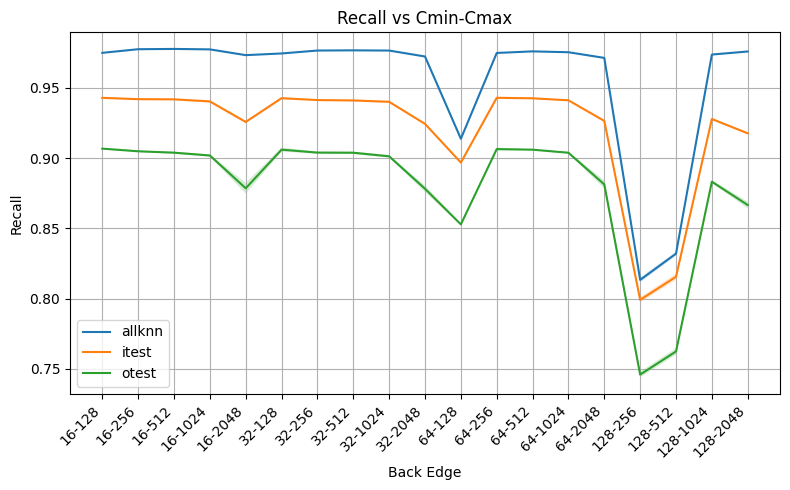

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("./results/cmaxcmin.csv")
# beam = df["BEAM_WIDTH"].unique()
# data = []
# bs = []
# for b in beam:
#     data.append(df.loc[df["BEAM_WIDTH"] == b, list(df.columns[df.columns.str.contains(f"{b}")]) + ["BEAM_WIDTH", "SEED", "build_time_s", "max_depth"]])
#     bs.append(b)
# data_r = []
# for i, d in enumerate(data):
#     res = d.groupby("BEAM_WIDTH")[
#     [f"allknn_bw{bs[i]}_recall", f"itest_bw{bs[i]}_recall", f"otest_bw{bs[i]}_recall"]
#     ].agg(["mean", "std"])

#     res.columns = [f"{col}_{stat}" for col, stat in res.columns]
#     res.columns = res.columns.str.replace(f"_bw{bs[i]}", "", regex=False)
#     res = res.reset_index()
#     data_r.append(res)

# res = pd.concat(data_r, ignore_index=True)
df["LEAF_MIN"] = df["MIN_LEAF_SIZE"].astype(int)
df["LEAF_MAX"] = df["LEAF_SIZE"].astype(int)

df["LEAF_PARAM"] = df["LEAF_MIN"].astype(str) + "-" + df["LEAF_MAX"].astype(str)

res = df.groupby("LEAF_PARAM")[["allknn_recall", "itest_recall", "otest_recall"]].agg(["mean", "std"])
res.columns = [f"{col}_{stat}" for col, stat in res.columns]
res = res.reset_index()

# recuperar columnas numéricas para ordenar correctamente
res[["LEAF_MIN", "LEAF_MAX"]] = res["LEAF_PARAM"].str.split("-", expand=True).astype(int)

res = res.sort_values(["LEAF_MIN", "LEAF_MAX"])


plt.figure(figsize=(8, 5))

# allknn
plt.plot(
    res["LEAF_PARAM"],
    res["allknn_recall_mean"],
    label="allknn"
)
plt.fill_between(
    res["LEAF_PARAM"],
    res["allknn_recall_mean"] - res["allknn_recall_std"],
    res["allknn_recall_mean"] + res["allknn_recall_std"],
    alpha=0.2
)

# itest
plt.plot(
    res["LEAF_PARAM"],
    res["itest_recall_mean"],
    label="itest"
)
plt.fill_between(
    res["LEAF_PARAM"],
    res["itest_recall_mean"] - res["itest_recall_std"],
    res["itest_recall_mean"] + res["itest_recall_std"],
    alpha=0.2
)

# otest
plt.plot(
    res["LEAF_PARAM"],
    res["otest_recall_mean"],
    label="otest"
)
plt.fill_between(
    res["LEAF_PARAM"],
    res["otest_recall_mean"] - res["otest_recall_std"],
    res["otest_recall_mean"] + res["otest_recall_std"],
    alpha=0.2
)

plt.xlabel("Back Edge")
plt.ylabel("Recall")
plt.title("Recall vs Cmin-Cmax")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./images/recall_Cmin_Cmax.png")
plt.show()

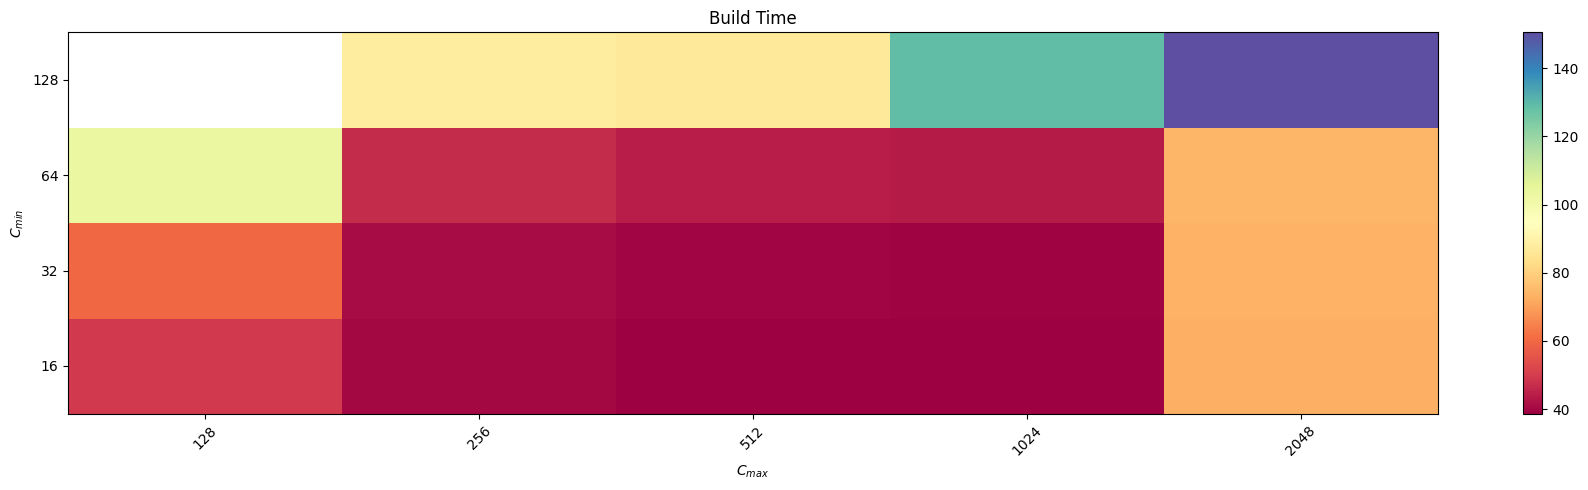

In [8]:
import matplotlib.colors as mcolors
import seaborn as sns
df = pd.read_csv("./results/cmaxcmin.csv")

df["LEAF_MIN"] = df["MIN_LEAF_SIZE"].astype(int)
df["LEAF_MAX"] = df["LEAF_SIZE"].astype(int)

agg = df.groupby(["LEAF_MIN", "LEAF_MAX"], as_index=False).agg({
    "build_time_s": "mean",
    "allknn_recall": "mean",
    "itest_recall": "mean",
    "otest_recall": "mean"
})

def plot_heatmap(data, value_col, title, ax):
    pivot = data.pivot_table(
        index="LEAF_MIN",
        columns="LEAF_MAX",
        values=value_col
    )
    cmap = sns.color_palette("Spectral", as_cmap=True)
    im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap=cmap)

    ax.set_title(title)
    ax.set_xlabel(r"$C_{max}$")
    ax.set_ylabel(r"$C_{min}$")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    plt.colorbar(im, ax=ax)

fig, axes = plt.subplots(1, 1, figsize=(18, 5))

plot_heatmap(df, "build_time_s", "Build Time", axes)

plt.tight_layout()
plt.savefig("./images/heatmaps_wall_time.png")
plt.show()

In [93]:
df

,exp_id,MIN_LEAF_SIZE,LEAF_SIZE,SEED,build_time_s,avg_degree,max_depth,allknn_recall,allknn_qps,itest_recall,itest_qps,otest_recall,otest_qps,wall_time_s,LEAF_MIN,LEAF_MAX
0,1,16,128,42,49.39,44.6,5.0,0.9750,23321.0,0.9431,22860.0,0.9074,22393.0,55.81,16,128
1,2,16,128,128,49.56,44.6,4.0,0.9748,23519.0,0.9426,23053.0,0.9069,22409.0,56.54,16,128
2,3,16,128,5,49.48,44.4,4.0,0.9749,23746.0,0.9434,23168.0,0.9065,22695.0,56.47,16,128
3,4,16,128,23,49.19,44.5,5.0,0.9750,23688.0,0.9430,23457.0,0.9067,23041.0,56.26,16,128
4,5,16,128,47,49.26,44.6,4.0,0.9749,23692.0,0.9423,23556.0,0.9062,22829.0,56.26,16,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,96,128,2048,42,144.98,29.1,2.0,0.9759,31666.0,0.9184,31091.0,0.8677,30925.0,150.83,128,2048
91,97,128,2048,128,150.78,29.0,2.0,0.9761,32172.0,0.9185,31587.0,0.8680,31231.0,156.60,128,2048
92,98,128,2048,5,149.84,28.7,2.0,0.9756,32674.0,0.9167,32248.0,0.8625,31938.0,155.60,128,2048
93,99,128,2048,23,154.86,29.0,2.0,0.9755,32576.0,0.9170,32001.0,0.8665,31641.0,160.65,128,2048


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10856\273232329.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby("BACK_EDGE").agg({


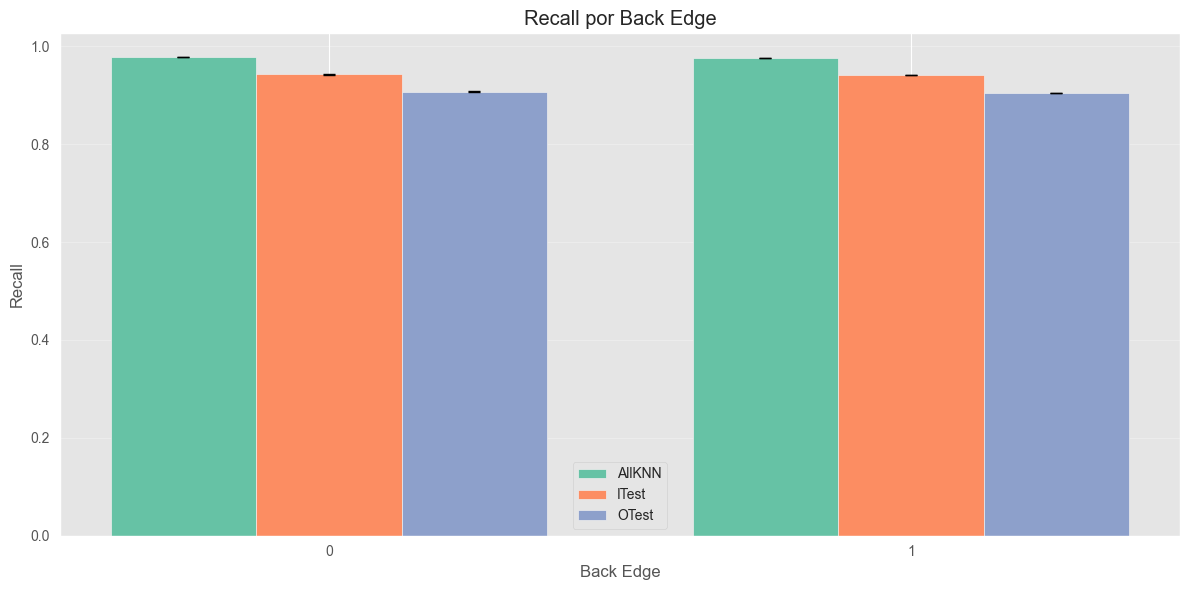

In [71]:
colors = ["#66c2a5", "#fc8d62", "#8da0cb"]
stats = df.groupby("BACK_EDGE").agg({
    "allknn_recall": ["mean", "std"],
    "itest_recall": ["mean", "std"],
    "otest_recall": ["mean", "std"],
})

# Aplanar nombres
stats.columns = [f"{c}_{s}" for c, s in stats.columns]
stats = stats.reset_index()

x = np.arange(len(stats))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    stats["allknn_recall_mean"],
    width,
    yerr=stats["allknn_recall_std"],
    capsize=4,
    color=colors[0],
    label="AllKNN"
)

plt.bar(
    x,
    stats["itest_recall_mean"],
    width,
    yerr=stats["itest_recall_std"],
    capsize=4,
    color=colors[1],
    label="ITest"
)

plt.bar(
    x + width,
    stats["otest_recall_mean"],
    width,
    yerr=stats["otest_recall_std"],
    capsize=4,
    color=colors[2],
    label="OTest"
)

plt.xticks(x, stats["BACK_EDGE"])
plt.xlabel("Back Edge")
plt.ylabel("Recall")
plt.title("Recall por Back Edge")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("./images/recall_back_edge.png")
plt.show()

In [ ]:
df_long = pd.melt(
    df,
    id_vars=["BACK_EDGE", "wall_time_s"],
    value_vars=["allknn_recall", "itest_recall", "otest_recall"],
    var_name="label",
    value_name="recall"
)

# Limpiar nombres
df_long["label"] = (
    df_long["label"]
    .str.replace("_recall", "", regex=False)
    .str.upper()
)

# Agrupar por BACK_EDGE y tipo
stats = (
    df_long.groupby(["BACK_EDGE", "label"])["wall_time_s"]
    .agg(["mean", "std"])
    .reset_index()
)

print(stats)

  BACK_EDGE   label    mean       std
0         0  ALLKNN  64.260  0.659242
1         0   ITEST  64.260  0.659242
2         0   OTEST  64.260  0.659242
3         1  ALLKNN  74.164  2.083382
4         1   ITEST  74.164  2.083382
5         1   OTEST  74.164  2.083382


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10856\2191237901.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long.groupby(["BACK_EDGE", "label"])["wall_time_s"]


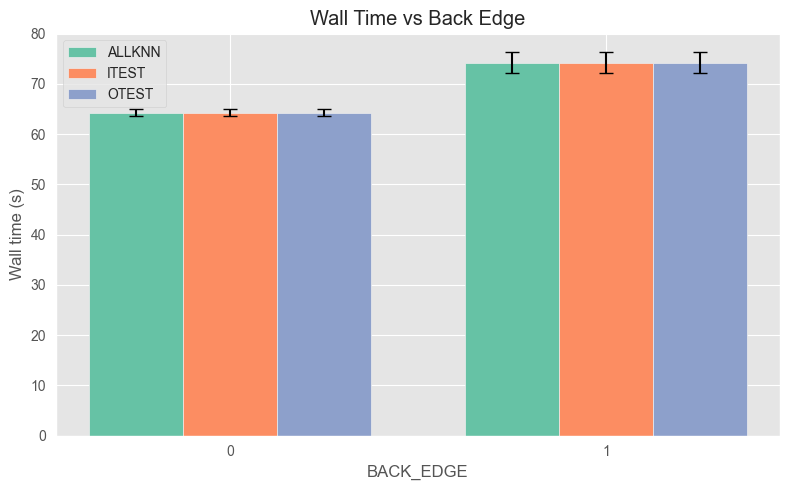

In [86]:
plt.style.use("ggplot")

labels = ["ALLKNN", "ITEST", "OTEST"]
colors = ["#66c2a5", "#fc8d62", "#8da0cb"]

x = np.arange(2)  # BACK_EDGE = 0 y 1
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

for i, label in enumerate(labels):
    d = stats[stats["label"] == label]

    ax.bar(
        x + (i - 1) * width,
        d["mean"],
        width,
        yerr=d["std"],
        capsize=5,
        color=colors[i],
        label=label,
    )

ax.set_xticks(x)
ax.set_xticklabels([0, 1])
ax.set_xlabel("BACK_EDGE")
ax.set_ylabel("Wall time (s)")
ax.legend()

plt.title(f"Wall Time vs Back Edge")
plt.tight_layout()
plt.savefig("./images/time_back_edges.png")
plt.show()

In [60]:
df

,exp_id,BACK_EDGE,SEED,build_time_s,avg_degree,max_depth,allknn_recall,allknn_qps,itest_recall,itest_qps,otest_recall,otest_qps,wall_time_s
0,1,0,42,48.76,47.9,2.0,0.9774,6426.0,0.9423,5524.0,0.9060,5273.0,64.88
1,2,0,128,48.85,48.0,3.0,0.9776,6599.0,0.9425,5738.0,0.9080,5663.0,64.59
2,3,0,5,48.73,47.8,2.0,0.9775,6868.0,0.9421,5646.0,0.9065,5636.0,64.35
3,4,0,23,48.47,47.7,2.0,0.9772,6446.0,0.9432,5930.0,0.9076,5897.0,64.33
4,5,0,47,48.97,47.9,2.0,0.9772,7725.0,0.9422,7549.0,0.9076,6236.0,63.15
5,6,1,42,61.72,44.2,2.0,0.9769,6801.0,0.9410,6448.0,0.9040,6302.0,76.75
6,7,1,128,61.54,44.3,3.0,0.9771,7220.0,0.9413,7585.0,0.9051,7167.0,75.85
7,8,1,5,59.63,44.1,2.0,0.9768,7967.0,0.9409,7717.0,0.9041,7355.0,73.15
8,9,1,23,58.19,44.1,2.0,0.9766,7926.0,0.9426,7747.0,0.9053,7243.0,71.67
9,10,1,47,58.51,44.2,2.0,0.9766,6947.0,0.9410,6321.0,0.9036,6116.0,73.40


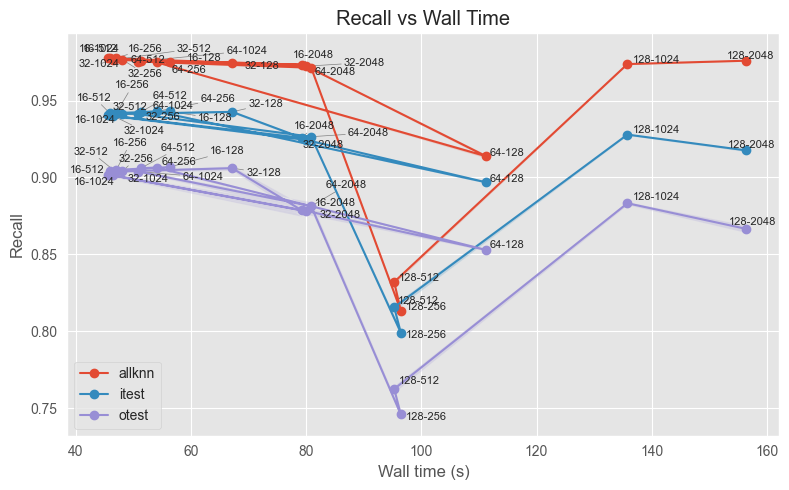

In [ ]:
# Media y std del tiempo

from adjustText import adjust_text

time = (
    df.groupby("LEAF_PARAM")["wall_time_s"]
      .agg(["mean", "std"])
      .reset_index()
)

# Añadir tiempo al dataframe de recalls
res = res.merge(time, on="LEAF_PARAM")
print
recalls = ["allknn", "itest", "otest"]
plt.figure(figsize=(8, 5))
for recall in recalls:
    plt.plot(
        res["mean"],                    # build_time medio
        res[f"{recall}_recall_mean"],   # recall medio
        "-o",
        label=recall
    )

    plt.fill_between(
        res["mean"],
        res[f"{recall}_recall_mean"] - res[f"{recall}_recall_std"],
        res[f"{recall}_recall_mean"] + res[f"{recall}_recall_std"],
        alpha=0.2
    )

    # Opcional: mostrar el beam width en cada punto
    texts = []

    for _, row in res.iterrows():
        texts.append(
            plt.text(
                row["mean"],
                row[f"{recall}_recall_mean"],
                str(row["LEAF_PARAM"]),
                fontsize=8
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )
    # for _, row in res.iterrows():
    #     plt.scatter(
    #         row["mean"],
    #         row[f"{recall}_recall_mean"],
    #     )
plt.xlabel("Wall time (s)")
plt.ylabel("Recall")
plt.title(f"Recall vs Wall Time")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("./images/time_Cmin_Cmax.png")
plt.show()

In [26]:
data_r[2]

,BEAM_WIDTH,allknn_recall_mean,allknn_recall_std,itest_recall_mean,itest_recall_std,otest_recall_mean,otest_recall_std
0,32,0.9767,0.000212,0.94104,0.000723,0.90382,0.000835
